## Setup

In [5]:
# Install if needed
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

## Load data

In [7]:
# Load one chromosome file
df = pd.read_csv("kg_matrix_chr1.csv")

# Inspect
print(df.head())
print(df.shape)

   Unnamed: 0  NA19024  HG03117  NA19120  HG03492  NA19238  NA19148  HG01956  \
0           0     23.0     23.0     23.5     23.0     24.0     23.0     23.0   
1           1     24.5     25.0     25.0     26.0     24.5     25.0     25.5   
2           2     19.0     19.0     18.0     19.0     19.0     21.0     19.0   
3           3     20.5     23.0     23.0     22.0     23.0     20.5     23.0   
4           4     13.0     13.0     13.0     10.5     10.5     13.0     13.0   

   HG00284  NA19404  ...  HG02220  NA18548  NA18966  HG03123  HG02923  \
0     24.0     23.0  ...     23.0     23.0     23.5     23.0     23.0   
1     25.0     25.0  ...     24.0     24.0     24.5     25.5     26.0   
2     19.0     18.0  ...     20.0     19.0     19.0     20.5     18.0   
3     20.5     23.0  ...     22.0     23.0     23.0     22.0     23.0   
4     10.5      8.0  ...     10.5      8.0      8.0     13.0     10.5   

   HG00409  HG01872  HG01805  HG02429  NA18957  
0     23.0     23.0     23.0   

## Filtering

In [8]:
# Drop columns with too many missing values
df = df.dropna(axis=1, thresh=int(0.9 * len(df)))

# Fill remaining missing values with column mean
df = df.fillna(df.mean())

# Remove low variance features
variance_threshold = 0.01
variances = df.var()
df = df.loc[:, variances > variance_threshold]

print("Filtered shape:", df.shape)

Filtered shape: (30635, 3203)


## Separate Features & Labels

In [9]:
# If population labels exist
if "population" in df.columns:
    y = df["population"]
    X = df.drop(columns=["population"])
else:
    y = None
    X = df

## Standardization

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## PCA analysis

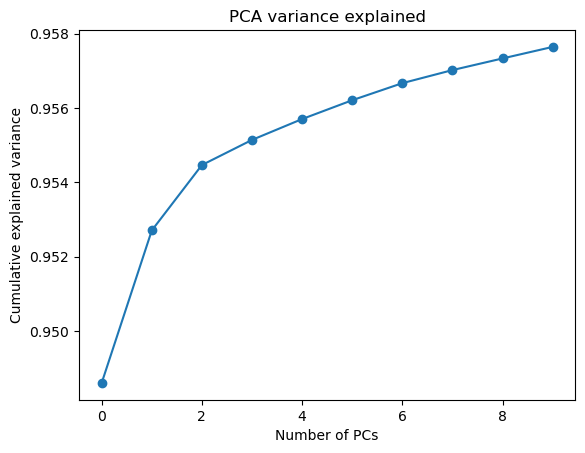

In [11]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.title("PCA variance explained")
plt.show()

## Visualization

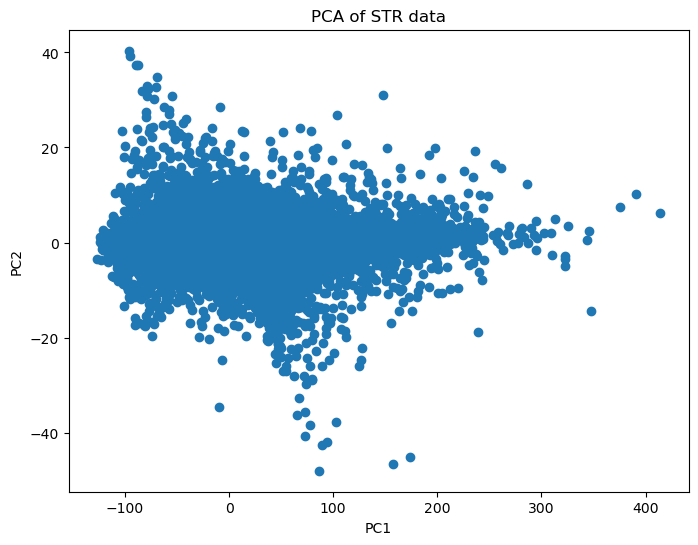

In [12]:
plt.figure(figsize=(8,6))

if y is not None:
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="tab10")
else:
    plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of STR data")
plt.show()

## Clustering

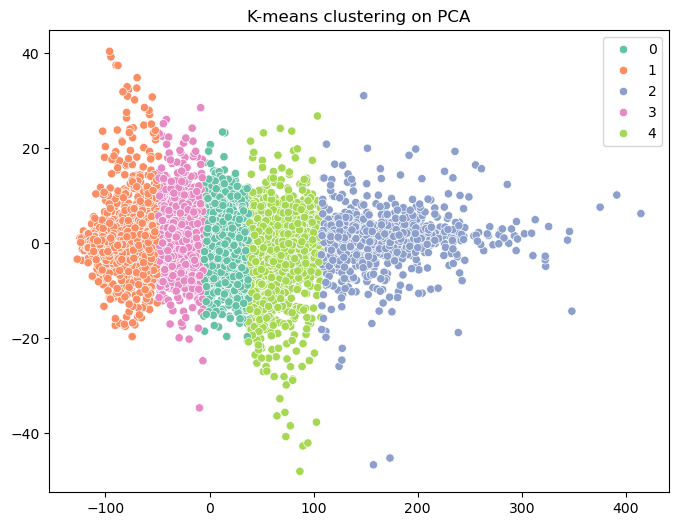

In [16]:
# Choose number of clusters (adjust as needed)
k = 5

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :5])  # use top PCs

# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set2")
plt.title("K-means clustering on PCA")
plt.show()

Clustering with k=5 not very convincing (different than the STR analysis)

## Classification

In [14]:
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca[:, :5], y, test_size=0.2, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [15]:
if y is not None:
    pd.crosstab(y, clusters, rownames=['True'], colnames=['Cluster'])